# Análisis exploratorio de datos (EDA)

## Librerías

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
import warnings
warnings.filterwarnings('ignore')

# Configurar visualización
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

## Asignar nombres de columnas en el dataset

In [3]:
# Nombres de columnas
nombres = [
    "wkblk", "wknwy", "wkna8", "wkona", "wkspr", "wkxbq", "wkxcr", "wkxbp",
    "whxbp", "wxqsq", "cntxt", "dsopp", "dwipd", "hdchk", "katri", "mulch",
    "qxmsq", "r2ar8", "reskd", "reskr", "rimmx", "rkxwp", "rxmsq", "simpl",
    "skach", "skewr", "skrxp", "spcop", "stlmt", "thrsk", "bkcti", "bkna8",
    "bknck", "bkovl", "bkpos", "btoeg", "class"
]


## Análisis de la variable target "class"

In [17]:
# Configurar pandas para mostrar todas las filas
pd.set_option('display.max_rows', None)

# Cargar datos
datos = pd.read_csv("kr-vs-kp.data", header=None, names=nombres)

for col in datos.columns:
    datos[col] = datos[col].astype('category')

print(f"Dimensiones: {datos.shape[0]} filas, {datos.shape[1]} columnas")

# Resumen
resumen = pd.DataFrame({
    'Variable': datos.columns,
    'Tipo': datos.dtypes.values,
    'Nulos': datos.isnull().sum().values,
    'Categorias': [datos[col].nunique() for col in datos.columns]
})

display(resumen)

Dimensiones: 3196 filas, 37 columnas


,Variable,Tipo,Nulos,Categorias
0,wkblk,category,0,2
1,wknwy,category,0,2
2,wkna8,category,0,2
3,wkona,category,0,2
4,wkspr,category,0,2
5,wkxbq,category,0,2
6,wkxcr,category,0,2
7,wkxbp,category,0,2
8,whxbp,category,0,2
9,wxqsq,category,0,2


In [37]:
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Tabla de frecuencias
tabla_target = datos['class'].value_counts().reset_index()
tabla_target.columns = ['class', 'Frecuencia']
tabla_target['Porcentaje'] = round((tabla_target['Frecuencia'] / tabla_target['Frecuencia'].sum()) * 100, 1)
tabla_target['Etiqueta'] = tabla_target['Frecuencia'].astype(str) + " (" + tabla_target['Porcentaje'].astype(str) + "%)"

print("Tabla de frecuencias de class:")
display(tabla_target)

fig_bar = px.bar(
    tabla_target,
    x='class',
    y='Frecuencia',
    color='class',
    color_discrete_map={'nowin': '#E74C3C', 'won': '#2E86C1'},
    text='Etiqueta',
    title='Distribución de la variable target',
    labels={'class': 'Clase', 'Frecuencia': 'Frecuencia'}
)

fig_bar.update_traces(
    textposition='outside',
    textfont=dict(size=14, color='black')
)

fig_bar.update_layout(
    height=500,
    width=700,
    showlegend=False,
    yaxis=dict(title='Frecuencia', range=[0, tabla_target['Frecuencia'].max() * 1.15]),
    xaxis=dict(title='Clase')
)

fig_bar.show()


fig_pie = px.pie(
    tabla_target,
    values='Frecuencia',
    names='class',
    color='class',
    color_discrete_map={'nowin': '#E74C3C', 'won': '#2E86C1'},
    title='Distribución de la variable target',
    hole=0.3  # Para que sea un donut (0 = torta, 0.3 = donut)
)

fig_pie.update_traces(
    textposition='inside',
    textinfo='label+percent',
    textfont=dict(size=14, color='white'),
    pull=[0.05, 0]  # Resaltar la primera porción
)

fig_pie.update_layout(
    height=500,
    width=700,
    showlegend=True,
    legend=dict(title='Clase', orientation='h', y=-0.1, x=0.5)
)

fig_pie.show()

Tabla de frecuencias de class:


,class,Frecuencia,Porcentaje,Etiqueta
0,won,1669,52.2,1669 (52.2%)
1,nowin,1527,47.8,1527 (47.8%)


En 1669 partidas, el 52.2%, resultó 'won', es decir que las blancas ganaron, y en 1527 partidas, el 47.8%, resultó 'nowin', es decir que el peón negro logró coronar o las negras consiguieron tablas; la diferencia entre ambas clases es de solo 4.4 puntos porcentuales, lo que indica que el dataset no tiene un sesgo significativo hacia ninguna clase.

## Análisis de las variables independientes

In [35]:
# Configurar pandas para mostrar todas las filas
pd.set_option('display.max_rows', None)

# Calcular frecuencias
vars_predictoras = [col for col in datos.columns if col != 'class']

frecuencias_list = []
for var in vars_predictoras:
    for valor in datos[var].unique():
        n = (datos[var] == valor).sum()
        pct = round((n / len(datos)) * 100, 1)
        frecuencias_list.append({'variable': var, 'valor': valor, 'n': n, 'porcentaje': pct})

frecuencias = pd.DataFrame(frecuencias_list)

# Variables binarias
binarias = frecuencias[frecuencias.groupby('variable')['valor'].transform('nunique') == 2]
binarias_pivot = binarias.pivot(index='variable', columns='valor', values='porcentaje').fillna(0)
print("Variables binarias (2 niveles):")
display(binarias_pivot)

# Variables ternarias
ternarias = frecuencias[frecuencias.groupby('variable')['valor'].transform('nunique') == 3]
ternarias_pivot = ternarias.pivot(index='variable', columns='valor', values='porcentaje').fillna(0)
print("\nVariables ternarias (3 niveles):")
display(ternarias_pivot)

Variables binarias (2 niveles):


valor,f,g,l,n,t
variable,,,,,
bkcti,82.3,0.0,0.0,0.0,17.7
bkna8,94.5,0.0,0.0,0.0,5.5
bknck,62.1,0.0,0.0,0.0,37.9
bkovl,37.2,0.0,0.0,0.0,62.8
bkpos,26.6,0.0,0.0,0.0,73.4
btoeg,0.0,0.0,0.0,75.3,24.7
cntxt,56.9,0.0,0.0,0.0,43.1
dsopp,89.5,0.0,0.0,0.0,10.5
dwipd,0.0,31.0,69.0,0.0,0.0



Variables ternarias (3 niveles):


valor,b,n,w
variable,,,
katri,7.0,79.0,14.0


Se muestra el porcentaje de cada característica (`t`, `f`, `n`, `b`, `g`, `l`) para cada variable, en particular, solo 2 de alguna de las 6, ya que son binarias. Se puede observar que la mayoría poseen `t` y `f`, true y false, a excepción de `dwipd`, con `g` y `l`. 

Se muestra el porcentaje de cada característica (`n`, `b`, `w`) para la variable ternaria.

In [7]:
colores_personalizados = {
    't': '#2E86C1',   # Azul
    'f': '#E74C3C',   # Rojo
    'n': '#95A5A6',   # Gris
    'b': '#4A4A4A',   # Gris oscuro
    'w': '#F39C12',   # Naranja
    'g': '#27AE60',   # Verde
    'l': '#8E44AD'    # Morado
}

# Crear subplot con 9 filas x 4 columnas
fig = make_subplots(
    rows=9, cols=4,
    specs=[[{'type': 'pie'} for _ in range(4)] for _ in range(9)],
    subplot_titles=vars_predictoras
)

# Añadir cada gráfico de pastel al subplot
row = 1
col = 1

for i, var in enumerate(vars_predictoras):
    # Calcular frecuencias
    tabla = datos[var].value_counts().reset_index()
    tabla.columns = ['valor', 'n']
    tabla['Porcentaje'] = round((tabla['n'] / tabla['n'].sum()) * 100, 1)
    tabla['Etiqueta'] = tabla['n'].astype(str) + " (" + tabla['Porcentaje'].astype(str) + "%)"
    
    # Colores
    colores_usar = [colores_personalizados.get(v, '#999999') for v in tabla['valor']]
    
    # Añadir al subplot
    fig.add_trace(
        go.Pie(
            labels=tabla['valor'],
            values=tabla['n'],
            text=tabla['Etiqueta'],
            textposition='inside',
            textinfo='text',
            marker=dict(colors=colores_usar),
            hoverinfo='label+percent+value',
            hovertemplate='<b>%{label}</b><br>Frecuencia: %{value}<br>Porcentaje: %{percent}<extra></extra>',
            showlegend=False,
            domain=dict(x=[0, 1], y=[0, 1])
        ),
        row=row, col=col
    )
    
    # Avanzar columna/fila
    col += 1
    if col > 4:
        col = 1
        row += 1

# Configurar layout general
fig.update_layout(
    title_text='Distribución de todas las variables predictoras',
    height=2800,
    width=1200,
    showlegend=False,
    font=dict(size=10)
)

fig.show()

whxbp: La torre blanca ataca al peón negro en el 38% de las posiciones .
wxqsq: Las blancas controlan la casilla de coronación (a8) en el 30.4% de las posiciones.
cntxt: El rey negro está en el borde del tablero en el 43.1% de las posiciones, lo que lo hace más vulnerable a clavadas.
También vemos que las tácticas avanzadas son extremadamente raras (Jaque oculto (hdchk) con 0.5%, re-clavada diferida (reskd) con 0.8%, oposición especial (spcop) con 0%, y clavada tras jaques (skach) con 0.3%), sin embargo, la posibilidad de una clavada (skewer) está presente en el 30.7% de las posiciones (skewr), lo que la convierte en una amenaza real.

**Variables del rey blanco (wk...)**:
Se observa que el rey blanco rara vez bloquea a su propia torre (wkblk: 88.8% falso) o se encuentra en a8 (wkna8: 96.2% falso). Sin embargo, en un porcentaje significativo de posiciones (36.6%), el rey blanco puede atacar la casilla crítica b7 (wkxcr), lo que indica que las blancas tienen oportunidades de presión sobre el peón negro.

**Variables del rey negro (bk...)**:
El rey negro está bajo presión en un porcentaje significativo de posiciones: en el 37.9% está en jaque (bknck), en el 37.2%** está sobrecargado (bkvol), y en el 26.6% está en posición de posible clavada (bkpos).

## Análisis bivariado class vs independientes

In [13]:
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from ipywidgets import interact, IntSlider, Dropdown
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    r, c = confusion_matrix.shape
    return np.sqrt(chi2 / (n * (min(r, c) - 1)))

vars_todas = datos.columns.tolist()
n_vars = len(vars_todas)
cramer_matrix = np.zeros((n_vars, n_vars))

for i, var1 in enumerate(vars_todas):
    for j, var2 in enumerate(vars_todas):
        cramer_matrix[i, j] = cramers_v(datos[var1], datos[var2])

cramer_df = pd.DataFrame(cramer_matrix, index=vars_todas, columns=vars_todas)

# Asociación con class
asociacion_class = cramer_df.loc['class'].drop('class').sort_values(ascending=False)

# Heatmap interactivo

fig_heatmap = go.Figure(data=go.Heatmap(
    z=cramer_df.values,
    x=cramer_df.columns,
    y=cramer_df.index,
    colorscale='Blues',
    zmin=0,
    zmax=1,
    text=np.round(cramer_df.values, 2),
    texttemplate='%{text:.2f}',
    textfont={"size": 8},
    hoverongaps=False,
    hovertemplate='<b>%{y}</b> ↔ <b>%{x}</b><br>Cramér\'s V: %{z:.3f}<extra></extra>'
))

fig_heatmap.update_layout(
    title='Matriz de asociación (Cramér\'s V) - KRKPA7',
    height=700,
    width=900,
    xaxis=dict(tickangle=90, tickfont=dict(size=8)),
    yaxis=dict(tickfont=dict(size=8)),
    margin=dict(l=50, r=50, t=80, b=120)
)

fig_heatmap.show()

# Top 5 variables más asociadas con class

top5_class = asociacion_class.head(5).reset_index()
top5_class.columns = ['Variable', 'Cramér\'s V']
top5_class['Porcentaje'] = (top5_class['Cramér\'s V'] * 100).round(1)

fig_top5 = px.bar(
    top5_class,
    x='Cramér\'s V',
    y='Variable',
    orientation='h',
    color='Cramér\'s V',
    color_continuous_scale='Blues',
    text=top5_class['Cramér\'s V'].apply(lambda x: f'{x:.3f}'),
    title='Top 5 variables más asociadas con class'
)

fig_top5.update_traces(
    textposition='outside',
    textfont=dict(size=13, color='black'),
    marker=dict(line=dict(width=1, color='darkblue'))
)

fig_top5.update_layout(
    height=400,
    width=700,
    showlegend=False,
    xaxis=dict(range=[0, 0.5], title='Cramér\'s V', tickformat='.3f'),
    yaxis=dict(title='', autorange='reversed'),
    margin=dict(l=10, r=40, t=50, b=30)
)

fig_top5.show()


El heatmap muestra la fuerza de la asociación entre las variables predictoras y la variable objetivo (`class`). 
Los valores más altos (azul oscuro) indican una relación más fuerte con el resultado del final de ajedrez. Los valores más bajos (blanco) sugieren que la variable es prácticamente independiente de si la posición es ganable o no.

El análisis de asociación con Cramér's V revela que las variables más relacionadas con el resultado (`won`/`nowin`) son:

`rimmx` (0.45): Captura segura de la torre blanca. Si la torre blanca puede ser capturada de forma segura por las negras, las blancas pierden su principal ventaja.
`wxqsq` (0.38): Control blanco de la casilla de coronación (a8). Si las blancas controlan a8, evitan que el peón negro corone.
`bknck` (0.365): Rey negro en jaque. Si el rey negro está en jaque, las blancas están haciendo una amenaza directa que puede llevar a la victoria.
`wkxbp` (0.233): Rey blanco captura el peón negro. Si el rey blanco puede capturar el peón, las blancas ganan de inmediato.
`katri` (0.22): Control del punto de intersección. Si el rey blanco controla el punto de intersección, puede evitar que su propia torre sea clavada.

Ahora miremos las cuentas de `won` y `nowin` para cada variable en una tabla de contingencia: 

In [38]:
# Configurar pandas para mostrar todas las filas
pd.set_option('display.max_rows', None)

# Crear tabla de contingencia
tabla_contingencia_list = []
for var in vars_predictoras:
    for class_val in datos['class'].unique():
        for cat in datos[var].unique():
            n = ((datos['class'] == class_val) & (datos[var] == cat)).sum()
            if n > 0:
                total_class = (datos['class'] == class_val).sum()
                pct = round((n / total_class) * 100, 1)
                tabla_contingencia_list.append({
                    'Class': class_val,
                    'Variable': var,
                    'Categoria': cat,
                    'Frecuencia': n,
                    'Porcentaje': pct
                })

tabla_contingencia = pd.DataFrame(tabla_contingencia_list)
tabla_contingencia = tabla_contingencia.sort_values(['Variable', 'Class'])

print("Tabla de contingencia:")
display(tabla_contingencia)

# Restaurar configuración por defecto
pd.set_option('display.max_rows', 10)

Tabla de contingencia:


,Class,Variable,Categoria,Frecuencia,Porcentaje
120,nowin,bkcti,f,1334,87.4
121,nowin,bkcti,t,193,12.6
118,won,bkcti,f,1297,77.7
119,won,bkcti,t,372,22.3
124,nowin,bkna8,f,1372,89.8
125,nowin,bkna8,t,155,10.2
122,won,bkna8,f,1649,98.8
123,won,bkna8,t,20,1.2
128,nowin,bknck,f,665,43.5
129,nowin,bknck,t,862,56.5


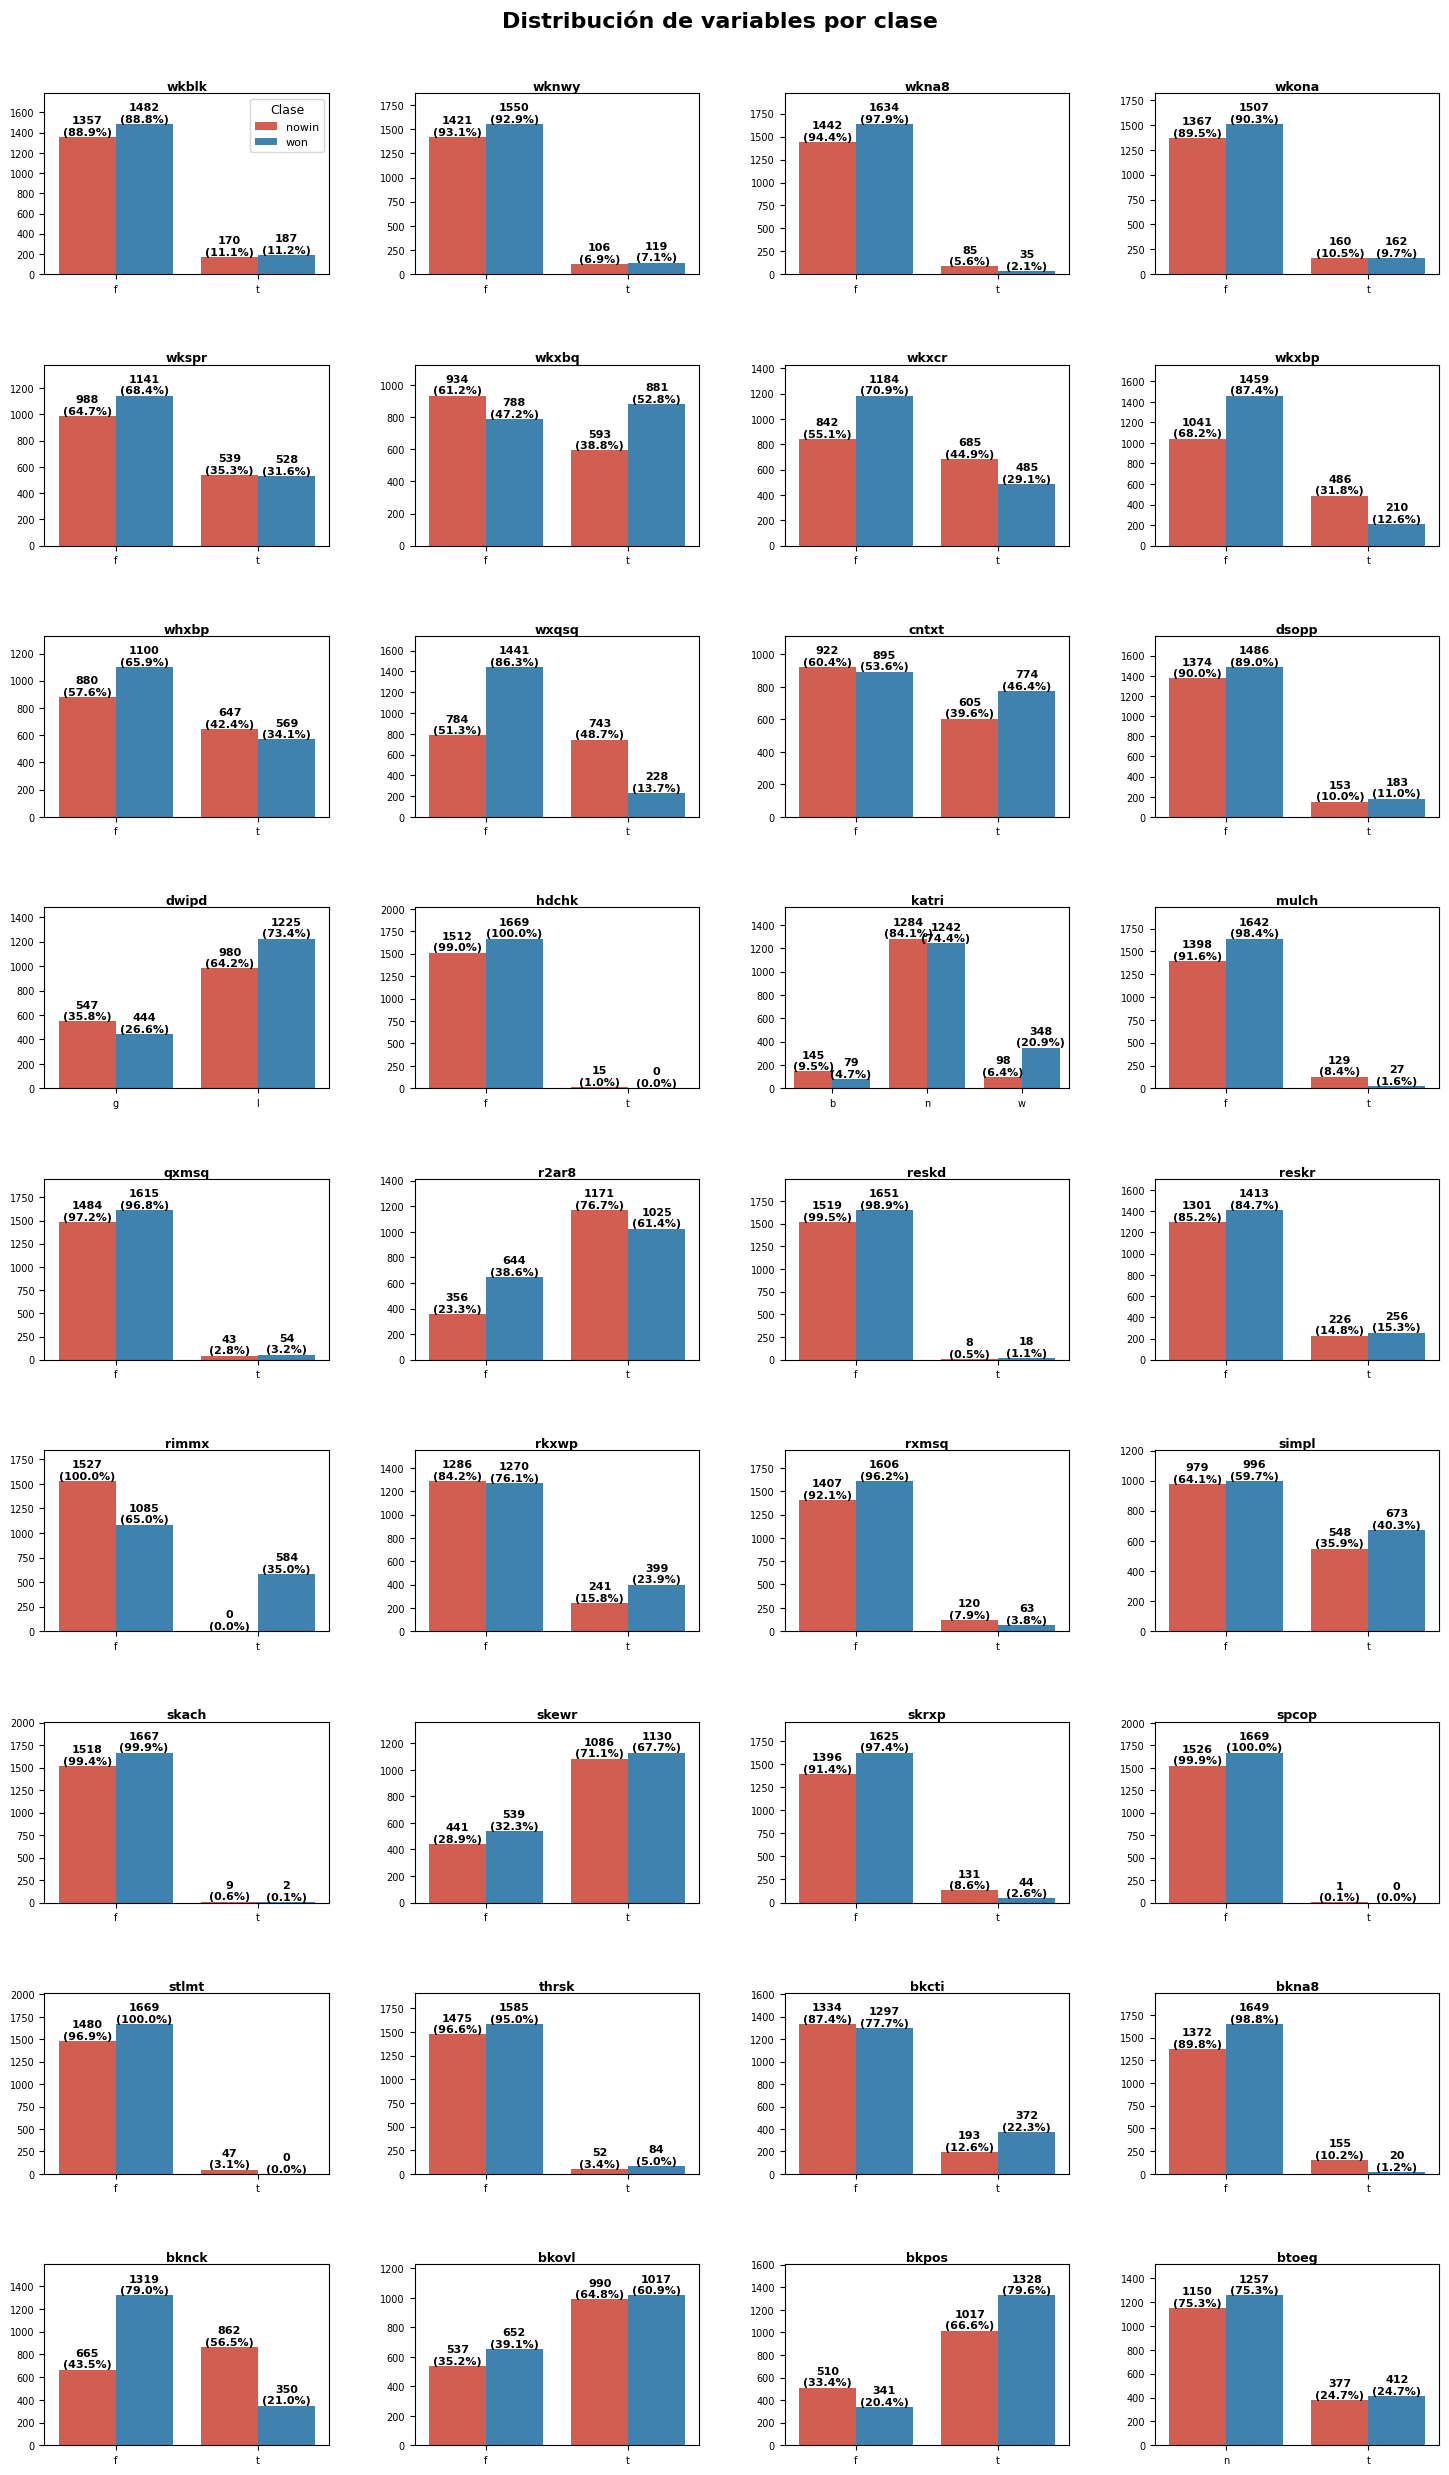

In [47]:
def graficar_barras_agrupadas(var, ax, mostrar_leyenda=False):
    df_plot = datos.groupby(['class', var]).size().reset_index(name='n')
    df_plot['porcentaje'] = df_plot.groupby('class')['n'].transform(lambda x: round(x / x.sum() * 100, 1))
    
    sns.barplot(data=df_plot, x=var, y='n', hue='class', ax=ax, palette=['#E74C3C', '#2E86C1'])
    
    for i, container in enumerate(ax.containers):
        if container is not None and len(container) > 0:
            try:
                n_values = [bar.get_height() for bar in container]
                class_val = 'nowin' if i == 0 else 'won'
                p_values = df_plot[df_plot['class'] == class_val]['porcentaje'].values[:len(n_values)]
                labels = [f'{int(h)}\n({p}%)' for h, p in zip(n_values, p_values)]
                ax.bar_label(container, labels=labels, fontsize=8, fontweight='bold')
            except:
                pass
    
    ax.set_title(var, fontsize=9, fontweight='bold', pad=2) 
    ax.set_xlabel('')
    ax.set_ylabel('')
    
    y_max = ax.get_ylim()[1]
    ax.set_ylim(0, y_max * 1.15)

    if mostrar_leyenda:
        ax.legend(loc='upper right', title='Clase', fontsize=8, title_fontsize=9)
    else:
        ax.legend().remove()
    
    ax.tick_params(axis='x', rotation=0, labelsize=7)
    ax.tick_params(axis='y', labelsize=7)


# Crear grid de gráficos
fig, axes = plt.subplots(9, 4, figsize=(18, 28))  # <--- MÁS PEQUEÑO
axes = axes.flatten()

for i, var in enumerate(vars_predictoras):
    mostrar_leyenda = (i == 0)
    graficar_barras_agrupadas(var, axes[i], mostrar_leyenda)

for j in range(len(vars_predictoras), len(axes)):
    axes[j].axis('off')

plt.subplots_adjust(top=0.95, hspace=0.5, wspace=0.3)  
plt.suptitle('Distribución de variables por clase', fontsize=16, fontweight='bold', y=0.98)
plt.show()  

**Factores asociados con la victoria (`won`)**:

`katri` (w): Cuando el rey blanco controla el punto de intersección (`katri = w`), la proporción de `won` (20.9%) es más del triple que en `nowin` (6.4%). Controlar el punto de intersección impide que la torre blanca sea clavada.

`rkxwp` (t): Cuando la torre blanca amenaza al peón negro (`rkxwp = t`), el 23.9% de los casos son `won` y el 15.8% son `nowin`. La amenaza de la torre sobre el peón favorece a las blancas, pero no es un factor determinante por sí solo.

`bkpos` (t): Cuando el rey negro está en posición de posible clavada (`bkpos = t`), es ligeramente más común en `won` (79.6%) que en `nowin` (66.6%). Sin embargo, la diferencia no es muy grande, lo que indica que no es un factor determinante por sí solo. La posición del rey negro en posible clavada puede favorecer a las blancas, pero otros factores son más importantes.

**Factores asociados con la no victoria (`nowin`)**:

`rimmx` (f): Cuando la torre blanca no puede ser capturada de forma segura por el rey negro (`rimmx = f`), se da el 100% de los casos de `nowin`. Esto significa que, si la torre está segura pero no puede atacar el peón, este corona sin oposición. Esta es la relación más fuerte.

`bkna8` (t): Cuando el rey negro está en a8 (`bkna8 = t`), es 5 veces más frecuente en `nowin` (10.2%) que en `won` (1.2%). Esto indica que la presencia del rey negro en a8 es un predictor fuerte de `nowin`, ya que el rey negro defiende la casilla de coronación y protege el peón.

`bknck` (t): Cuando el rey negro está en jaque (`bknck = t`), es 2.7 veces más frecuente en `nowin` (56.5%) que en `won` (21.0%). Esto indica que el jaque al rey negro no siempre es favorable para las blancas.

`wkxbp` (t): Cuando el rey blanco puede capturar el peón (`wkxbp = t`), es 2.5 veces más frecuente en `nowin` (31.8%) que en `won` (12.6%). Esto es contra intuitivo, ya que se esperaría que capturar el peón llevara a la victoria, pero los datos muestran lo contrario.

`wxqsq` (t): Cuando las blancas controlan la casilla de coronación a8 (`wxqsq = t`), es 3.5 veces más frecuente en `nowin` (48.7%) que en `won` (13.7%). Esto es contra intuitivo también.

**Variables con poca diferencia**:

Las variables `wkblk`, `wknwy`, `dsopp`, `qxmsq`, `reskd`, `reskr` y `btoeg` presentan distribuciones muy  entre `won` y `nowin`, lo que indica que podrían no ser útiles para predecir el resultado.

## Relaciones entre variables predictoras

In [51]:
vars_pred = [col for col in datos.columns if col != 'class']
n_pred = len(vars_pred)
cramer_pred = np.zeros((n_pred, n_pred))

for i, var1 in enumerate(vars_pred):
    for j, var2 in enumerate(vars_pred):
        cramer_pred[i, j] = cramers_v(datos[var1], datos[var2])

cramer_pred_df = pd.DataFrame(cramer_pred, index=vars_pred, columns=vars_pred)

# Heatmap interactivo

fig_heatmap = go.Figure(data=go.Heatmap(
    z=cramer_pred_df.values,
    x=cramer_pred_df.columns,
    y=cramer_pred_df.index,
    colorscale='Blues',
    zmin=0,
    zmax=1,
    text=np.round(cramer_pred_df.values, 2),
    texttemplate='%{text:.2f}',
    textfont={"size": 7},
    hoverongaps=False,
    hovertemplate='<b>%{y}</b> ↔ <b>%{x}</b><br>Cramér\'s V: %{z:.3f}<extra></extra>'
))

fig_heatmap.update_layout(
    title='Asociación entre variables predictoras (Cramér\'s V)',
    height=600,
    width=800,
    xaxis=dict(tickangle=90, tickfont=dict(size=7)),
    yaxis=dict(tickfont=dict(size=7)),
    margin=dict(l=50, r=50, t=80, b=120)
)

fig_heatmap.show()


# Calcular pares
pares_list = []
for i in range(n_pred):
    for j in range(i+1, n_pred):
        pares_list.append({'var1': vars_pred[i], 'var2': vars_pred[j], 'cramer': cramer_pred[i, j]})

pares_df = pd.DataFrame(pares_list)
top5_pares = pares_df.sort_values('cramer', ascending=False).head(5)
top5_pares['par'] = top5_pares['var1'] + ' ↔ ' + top5_pares['var2']
top5_pares['porcentaje'] = (top5_pares['cramer'] * 100).round(1)

# Gráfico interactivo
fig = px.bar(
    top5_pares,
    x='cramer',
    y='par',
    orientation='h',
    color='cramer',
    color_continuous_scale='Blues',
    text=top5_pares['cramer'].apply(lambda x: f'{x:.3f}'),
    title='Top 5 pares de variables predictoras con mayor asociación',
    labels={'cramer': 'Cramér\'s V', 'par': ''}
)

fig.update_traces(
    textposition='outside',
    textfont=dict(size=12, color='black')
)

fig.update_layout(
    height=400,
    width=800,
    showlegend=False,
    xaxis=dict(range=[0, 0.75], title='Cramér\'s V'),
    yaxis=dict(title='', autorange='reversed'),
    margin=dict(l=10, r=40, t=50, b=30)
)

fig.show()


Para evaluar si existen variables redundantes (que miden información similar), se calculó la matriz de Cramer's V excluyendo la variable objetivo `class`. Los valores más altos indican que dos variables están asociadas entre sí, lo que sugiere que podrían estar midiendo conceptos relacionados:

`whxbp` ↔ `wkxbp` (0.67) Captura del peón negro por la torre blanca vs captura por el rey blanco. Ambas miden si el peón puede ser capturado, lo que sugiere que están altamente relacionadas.

`rkxwp` ↔ `whxbp` (0.639) Amenaza de la torre blanca sobre el peón vs ataque de la torre blanca al peón. Miden conceptos similares, ambos de la torre blanca sobre el peón negro. 

`bkovl` ↔ `r2ar8` (0.591) Rey negro sobrecargado vs acceso de la torre blanca a la columna A o fila 8. Si la torre blanca tiene acceso, el rey negro se sobrecarga al tener que defender múltiples amenazas. 

`cntxt` ↔ `skewr` (0.579) Rey negro en el borde (no a8) vs posibilidad de clavada. Si el rey negro está en el borde, es más vulnerable a una clavada de la torre blanca.

`wkxbp` ↔ `wkxcr` (0.564) Rey blanco captura el peón vs rey blanco ataca b7. Ambas miden la capacidad del rey blanco para presionar al peón negro. 


Ninguno de estos valores superan el 0.7, lo que indica que no hay variables altamente redundantes, es decir, que presenten multicolinealidad muy alta. Sin embargo, las relaciones moderadas (0.5 - 0.67) sugieren que algunos pares de variables miden conceptos relacionados desde diferentes perspectivas.


## Conclusiones

El análisis exploratorio permitió identificar los principales factores que determinan el resultado 
del final de ajedrez Rey+Torre (blancas) vs Rey+Peón (negras) en a7.

1. La variable objetivo 'class' presenta una distribución prácticamente balanceada (52.2% won, 47.8% nowin).

2. La mayoría de las variables predictoras son binarias (t/f), con excepción de dwipd (g/l) y katri (única ternaria: n/b/w).

3. Tácticas avanzadas como el jaque oculto (hdchk, 0.5%), la re-clavada diferida (reskd, 0.8%), 
   la clavada tras jaques (skach, 0.3%) y la oposición especial (spcop, 0%) son muy raras.

4. La variable más determinante es rimmx (Cramér's V = 0.45): cuando la torre blanca no puede ser capturada 
   de forma segura (rimmx = f), se da el 100% de los casos de nowin.

5. Otras variables con alta asociación: wxqsq (0.38) y bknck (0.365).

6. No hay variables altamente redundantes (ninguna supera 0.7 de Cramér's V).

7. El resultado del final depende de la combinación de múltiples factores, destacando:
   - Seguridad de la torre (rimmx)
   - Control del punto de intersección (katri)
   - Posición del rey negro (bkna8, bknck)